امورت کردن کتابخانه های مربوط به خواندن داده و تمام کتابخانه های مربوط به الگوریتم های کلاسترینگ

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

خواندن داده

In [11]:
df = pd.read_csv("data.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# پیس پردازش داده ها
#### حذف ستون ایدی
#### تبدیل ستون جنسیت به عدد
#### انتخاب سه تا از ویژگی ها برای خوشه بندی

In [12]:
df = df.drop('CustomerID', axis=1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
X = df[[ 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# پیدا کردن تعداد خوشه ها به روش البو متد برای کا مینز
هرجا نمودار شکسته شد ان نقطه تعداد خوشه های مارا مشخص میکند
و طبق نمودار کلاستر مناسب برای ما5 میشود

C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

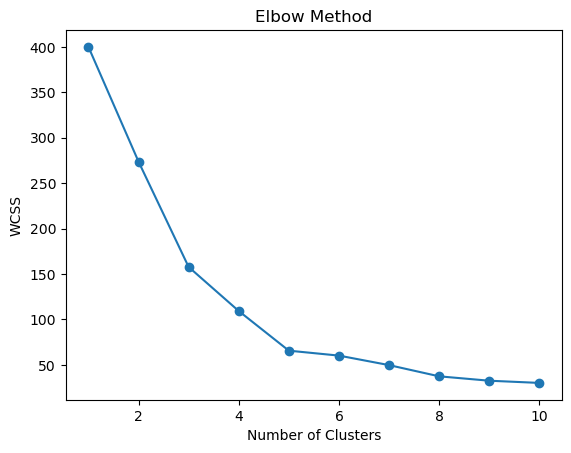

In [13]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster_KMeans'] = clusters


C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


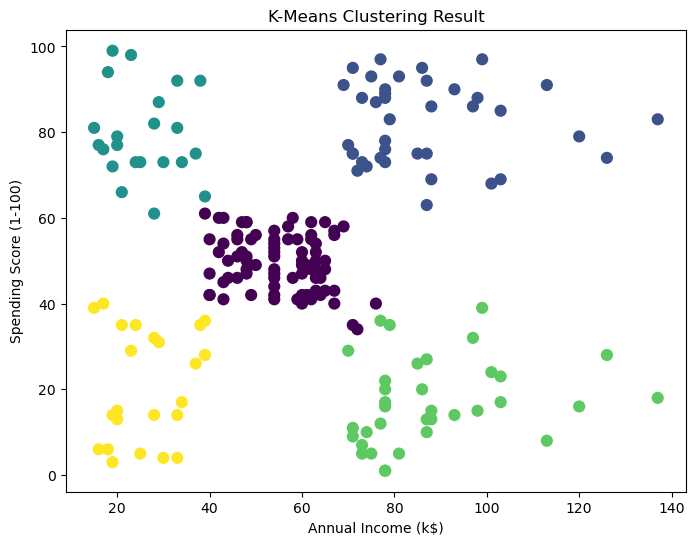

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=df['Cluster_KMeans'], 
    cmap='viridis', 
    s=60
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering Result')
plt.show()


در ابن قطعه کد زیر هم مشخص است که بهترین کا عدد 5 میباشد

In [16]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}  -->   {score:.4f}")

C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

K = 2  -->   0.3973
K = 3  -->   0.4666
K = 4  -->   0.4943
K = 5  -->   0.5547
K = 6  -->   0.5138
K = 7  -->   0.5020
K = 8  -->   0.4550
K = 9  -->   0.4567
K = 10  -->   0.4448


C:\Users\Farzad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# رسم نمودار دندروگرام برای اینکه تشخیص دهیم به چند خوشه باید تفکیک کنیم برای خوشه بندی به روش سلسله مراتبی
طبق این دندوگرام به 5 خوشه باید تقسیم کنیم

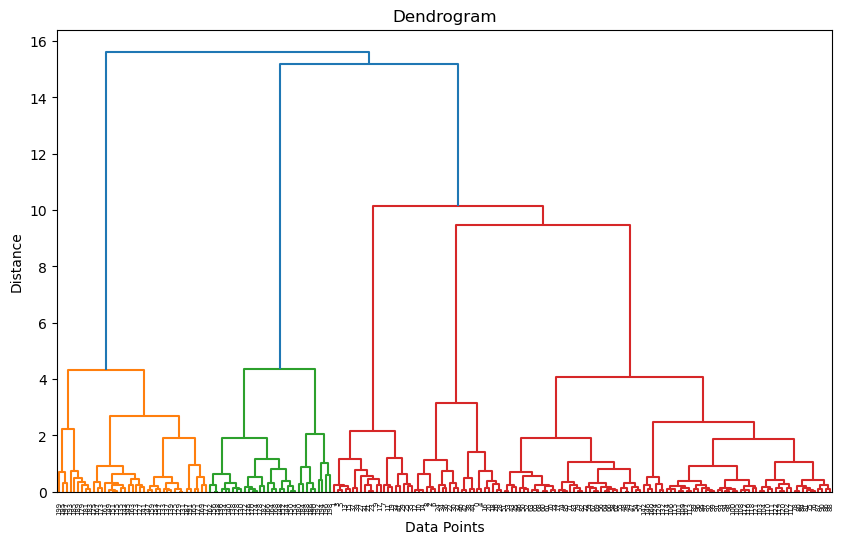

In [17]:

plt.figure(figsize=(10,6))

linked = linkage(X_scaled, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()


فیت کردن انها و کشیدن نمودار نقطه ای ان برای ارزیابی کلی

In [18]:

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')

labels_hc = hc.fit_predict(X_scaled)

df['Cluster_HC'] = labels_hc


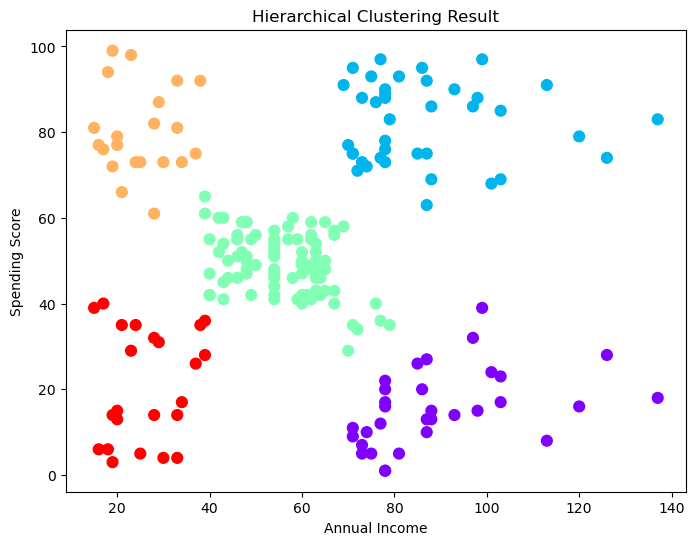

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster_HC'],
    cmap='rainbow',
    s=60
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering Result")

plt.show()


# انجام دادن به روش دی بی اسکن
همانطور که در نمودار ان پیداست به روش دی بی اسکن خیلی خوب در نیامدند

In [20]:

db = DBSCAN(eps=0.4, min_samples=5)

labels_db = db.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = labels_db


In [21]:
print(df['Cluster_DBSCAN'].value_counts())


Cluster_DBSCAN
 0    115
 2     32
 3     27
-1     15
 1     11
Name: count, dtype: int64


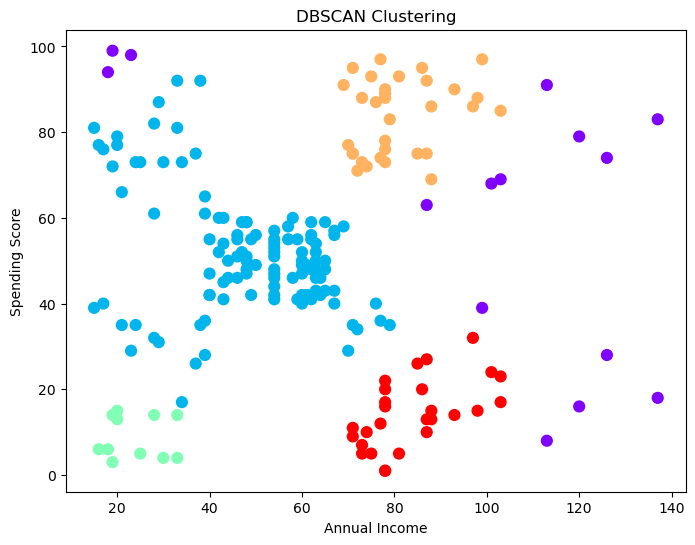

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster_DBSCAN'],
    cmap='rainbow',
    s=60
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")

plt.show()


# مقایسه روش ها

طبق نمودار ها فقط دو روش اول را باهم مقایسه میکنیم

In [23]:

score_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans'])
score_hc = silhouette_score(X_scaled, df['Cluster_HC'])

print("KMeans Silhouette Score:", score_kmeans)
print("Hierarchical Silhouette Score:", score_hc)


KMeans Silhouette Score: 0.5546571631111091
Hierarchical Silhouette Score: 0.5538089226688662
